# Customer Churn Prediction for Telecom Customer Retention

# 1.Business Understanding

## 1.1 Overview

The goal is to build a classification model that predicts customer churn. By identifying at-risk customers early, the business can reduce revenue loss and decrease the high marketing costs associated with acquiring new customers.

## 1.2 Stakeholders

#### Customer Retention & Marketing: 

To target at-risk customers with promotions.

#### Business Analysts & Management: 

To track churn trends and improve overall retention strategy.

## 1.3 Objective

To build a classification model that predicts customer churn using historical customer data.

## 1.4 Success Metrics

Recall is the primary success metric. Because the cost of losing a customer is significantly higher than the cost of an unnecessary discount, we prioritize identifying as many potential churners as possible.

## 1.5 Methodology

We will establish a Logistic Regression baseline and iterate toward a Tuned Decision Tree to maximize recall and identify key churn drivers.

## 1.6 Constraints

#### Data Gaps:

External factors (competitor pricing, network outages) are not captured in the dataset.

#### Class Imbalance: 

Churners typically represent a small fraction of the data, which may skew model performance.

# 2. Data Understanding

This section explores the dataset used for predicting customer churn. The goal is to understand the source, structure, and properties of the data, and evaluate how suitable it is for building a classification model to solve the business problem.

### 2.1. dataset

In [233]:
#1. confirming the path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
os.path.exists("../data/bigml_59c28831336c6604c800002a.csv")


True

In [234]:
# loading the dataset
df = pd.read_csv("../data/bigml_59c28831336c6604c800002a.csv")
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


### 2.2 Dataset Shape and data types

We check the number of rows and columns to understand the scale of the dataset.

In [235]:
# checking for data types
print("Data Types:")
print(df.dtypes)

Data Types:
state                      object
account length              int64
area code                   int64
phone number               object
international plan         object
voice mail plan            object
number vmail messages       int64
total day minutes         float64
total day calls             int64
total day charge          float64
total eve minutes         float64
total eve calls             int64
total eve charge          float64
total night minutes       float64
total night calls           int64
total night charge        float64
total intl minutes        float64
total intl calls            int64
total intl charge         float64
customer service calls      int64
churn                        bool
dtype: object


In [236]:
# check shape
df.shape

(3333, 21)

### 2.3 Sammary Statistics

We generate summary statistics for numerical features to understand distributions and variability in the data.

In [237]:
df.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


### 2.4 Feature Justification

The features in this dataset are relevant for predicting churn because they represent customer usage patterns, service plans, and account behavior.

Examples include:
- Call usage (day, evening, night minutes)
- Service plans (international plan, voicemail plan)
- Account activity (customer service calls)

These features are useful because customer behavior and service engagement are strong indicators of whether a customer is likely to churn.

# 3.Data preparation

### 3.1 data cleaning


In this section, we prepare the dataset for machine learning.

The goal is to transform the raw data into a clean and structured format suitable for building classification models. This includes:

- Handling irrelevant features
- Encoding categorical variables
- Splitting data into training and testing sets
- Scaling numerical features where necessary

These steps are essential to improve model performance and ensure reliable predictions.

### 3.2 Drop Irrelevant Columns

Some columns do not contribute to predicting churn and may introduce noise into the model.

For example:
- `phone number` is unique for each customer and has no predictive value.

Some columns in the dataset do not contribute to predicting customer churn.
For example, phone numbers are unique identifiers and do not contain predictive information.
These are removed to improve model performance and reduce noise.

In [238]:
# Drop columns that are not useful for modeling
df = df.drop(columns=['phone number'], errors='ignore')

### 3.3 ENCODE TARGET VARIABLE

Machine learning models require numerical input.
The target variable "churn" is converted into binary format:

1 = Customer churned
0 = Customer did not churn

In [239]:
# Convert target variable into binary format
df['churn'] = df['churn'].astype(int)

# Confirming the distribution after encoding
print(df['churn'].value_counts())

0    2850
1     483
Name: churn, dtype: int64


### 3.4. ENCODE BINARY FEATURES

Some features contain categorical values such as "yes" and "no".
These are converted into numerical values so that machine learning models can process them.

In [240]:
# Convert binary categorical features into numeric format
df['international plan'] = df['international plan'].map({'yes': 1, 'no': 0})
df['voice mail plan'] = df['voice mail plan'].map({'yes': 1, 'no': 0})

# Check unique values before mapping to avoid creating NaNs
print(df['international plan'].unique())

[0 1]


### 3.5. Encode cartegorical variable

The "state" column contains multiple categories.
One-hot encoding is used to convert it into separate binary columns.
This prevents the model from assuming any ordinal relationship between states.

In [241]:
# Apply one-hot encoding to the 'state' column
df = pd.get_dummies(df, columns=['state'], drop_first=True)

# Check new dataset shape
print("New dataset shape after encoding:", df.shape)


New dataset shape after encoding: (3333, 69)


### 3.6. HANDLE MISSING VALUES

Missing values can negatively affect model performance.
In this dataset, any rows with missing values are removed to ensure clean training data.

In [242]:
# Handle missing values (if any exist in target column)
df = df.dropna(subset=['churn'])

# Confirm missing values are removed
print("Total missing values after cleaning:", df.isnull().sum().sum())

Total missing values after cleaning: 0


### 3.7. DEFINE FEATURES AND TARGET

The dataset is split into features (X) and target (y).

X contains all input variables used for prediction

y contains the churn outcome we want to predict

In [243]:
# Define features and target variable
X = df.drop('churn', axis=1)
y = df['churn']

# Display shapes
print("Feature matrix shape (X):", X.shape)
print("Target vector shape (y):", y.shape)

# Check class distribution
print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape (X): (3333, 68)
Target vector shape (y): (3333,)

Target distribution:
0    2850
1     483
Name: churn, dtype: int64


# 4. Data analysis

This section focuses on understanding the dataset using numerical summaries and statistical relationships. The goal is to identify key patterns and factors that may influence customer churn.

### 4.1 Churn Distribution

the proportion of customers who churn versus those who do not

In [244]:
print("[4.1] Churn Distribution:")
print(df['churn'].value_counts(normalize=True))

[4.1] Churn Distribution:
0    0.855086
1    0.144914
Name: churn, dtype: float64


Approximately 85% of customers do not churn, while 15% churn.

This indicates a class imbalance problem.

Because of this imbalance, accuracy alone is not a reliable metric.

We prioritize Recall to ensure churners are correctly identified.

### 4.2 Customer service call analysis

Analysing whether customer dissatisfaction (measured by service calls) is linked to churn.

In [245]:
print("\n[4.2] Average Customer Service Calls by Churn:")
print(df.groupby('churn')['customer service calls'].mean())


[4.2] Average Customer Service Calls by Churn:
churn
0    1.449825
1    2.229814
Name: customer service calls, dtype: float64


Customers who churn make more service calls on average.

This suggests:


    -Higher dissatisfaction

    -Possible unresolved issues

Customer support quality is a key driver of churn.

### 4.3 Correlation Analysis

How strongly different features are related to churn.

In [246]:
corr = df.corr()['churn'].sort_values(ascending=False)

print("\n[4.3] Top Correlations with Churn:")
print(corr.head(10))


[4.3] Top Correlations with Churn:
churn                     1.000000
international plan        0.259852
customer service calls    0.208750
total day minutes         0.205151
total day charge          0.205151
total eve minutes         0.092796
total eve charge          0.092786
total intl charge         0.068259
total intl minutes        0.068239
state_NJ                  0.049111
Name: churn, dtype: float64



Customer service calls show the strongest positive correlation → strong churn indicator

Total day charge suggests pricing influences churn

International plan usage also relates to churn behavior

Overall correlations are moderate, meaning:
    -No single feature explains churn completely
    -Churn is influenced by a combination of factors

# 5. Data Visualisation

visualizations is used to explore patterns in the data and understand factors influencing customer churn.

### 5.1 Churn Distribution

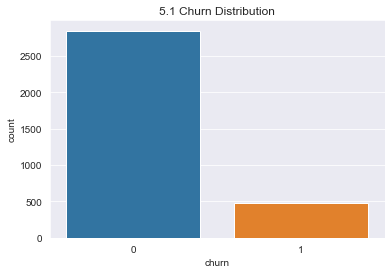

In [247]:
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df)
plt.title("5.1 Churn Distribution")
plt.show()

#### Insight

Majority of customers do not churn.

Confirms class imbalance (~85% vs ~15%).

Reinforces why Recall is the key metric.

### 5.3 Distribution of Total Day Minutes

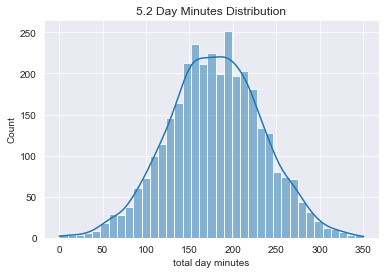

In [248]:
plt.figure(figsize=(6,4))
sns.histplot(df['total day minutes'], kde=True)
plt.title("5.2 Day Minutes Distribution")
plt.show()

#### Insight
Data is roughly normally distributed.

Most customers have moderate usage.

Few extreme high-usage customers (potential premium users).

### 5.3 Day Minutes vs Churn (KDE Plot)

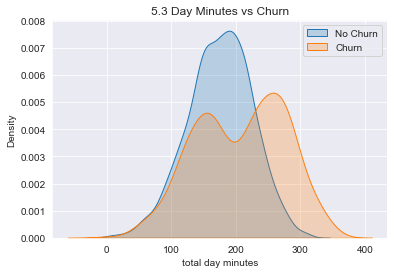

In [249]:
plt.figure(figsize=(6,4))
sns.kdeplot(df[df['churn']==0]['total day minutes'], label="No Churn", fill=True)
sns.kdeplot(df[df['churn']==1]['total day minutes'], label="Churn", fill=True)
plt.legend()
plt.title("5.3 Day Minutes vs Churn")
plt.show()

#### Insight
Churned customers tend to have slightly higher usage.

Suggests:
   -Higher usage → higher bills → possible dissatisfaction

Usage alone is not a strong separator, but still relevant.

### 5.4 Customer Service Calls vs Churn

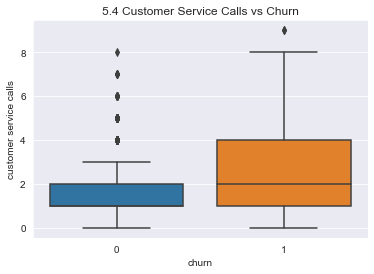

In [250]:
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='customer service calls', data=df)
plt.title("5.4 Customer Service Calls vs Churn")
plt.show()

#### Insight
Churned customers have more service calls.

Strong indication of:

-Poor customer experience

-Unresolved issues

This is one of the strongest churn drivers.

### 5.5 Correlation Heatmap

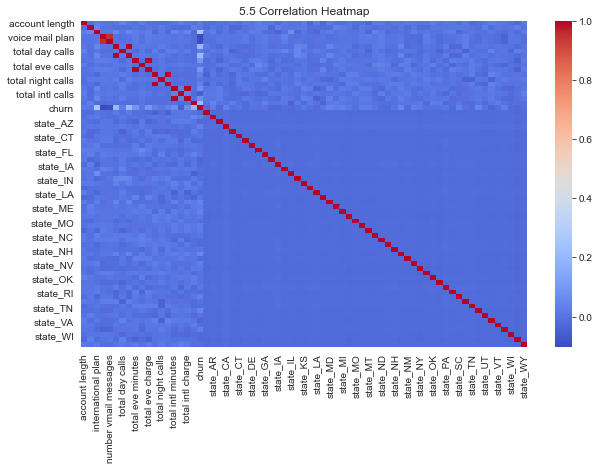

In [251]:
# Safe version (works on all pandas versions)
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("5.5 Correlation Heatmap")
plt.show()

#### Insight
No extremely strong correlations → no single dominant feature

Moderate relationships exist with:

    -Customer service calls

    -Charges (day/evening/international)

Indicates churn is influenced by multiple combined factors

In [252]:
print("\n[5] Key Visualization Insight: Churn is driven by cost and poor service experience.")


[5] Key Visualization Insight: Churn is driven by cost and poor service experience.


# 6. FEATURE ENGINEERING

Feature engineering involves creating new features or transforming existing ones to improve model performance.

In this project, minimal feature engineering is applied because the dataset already contains well-structured features.

In [253]:
# Define features and target variable
X = df.drop('churn', axis=1)
y = df['churn']

print("[6] Features and target variable defined")
print("Feature shape:", X.shape)

[6] Features and target variable defined
Feature shape: (3333, 68)


All relevant features are already available

No additional feature creation was necessary

Focus will be on model performance rather than feature construction

# 7. TRAIN-TEST SPLIT (NO DATA LEAKAGE)

The dataset is split into training and testing sets.
The training set is used to build the model, while the test set is used to evaluate performance on unseen data.
Stratification ensures the class distribution is preserved in both sets.

It is important to confirm that the data has been split correctly and that class distribution is balanced across training and testing sets.

In [254]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("[7] Train/Test split completed")

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

[7] Train/Test split completed
Training set shape: (2666, 68)
Test set shape: (667, 68)

Training distribution:
0    0.855214
1    0.144786
Name: churn, dtype: float64

Test distribution:
0    0.854573
1    0.145427
Name: churn, dtype: float64


Dataset successfully split into train (80%) and test (20%)

Class distribution is preserved → stratification worked

Ensures fair and reliable model evaluation

# 8. MODELLING

In this section, we build classification models to predict customer churn.
We begin with a baseline model for interpretability, then improve performance using a decision tree and hyperparameter tuning.
The primary evaluation metric is Recall, since correctly identifying customers who are likely to churn is more important than overall accuracy.

In [255]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, confusion_matrix


### 8.1 FEATURE SCALING

Feature scaling is applied to ensure that all variables contribute equally to the model.
Logistic Regression performs better when numerical features are standardized.

In [256]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data (prevents data leakage)
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

### 8.2 BASELINE MODEL (LOGISTIC REGRESSION)

Logistic Regression is used as a baseline model due to its simplicity and interpretability.

In [257]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [258]:
# Logistic Regression

from sklearn.metrics import classification_report, confusion_matrix, recall_score

print("=== Logistic Regression Results ===")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))

=== Logistic Regression Results ===
[[550  20]
 [ 71  26]]
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       570
           1       0.57      0.27      0.36        97

    accuracy                           0.86       667
   macro avg       0.73      0.62      0.64       667
weighted avg       0.84      0.86      0.84       667

Recall: 0.26804123711340205


### 8.3 DECISION TREE MODEL

Decision Trees are non-parametric models that do not require feature scaling and can capture non-linear relationships.

In [259]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [260]:
# Decision Tree
print("=== Decision Tree Results ===")
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))

=== Decision Tree Results ===
[[541  29]
 [ 35  62]]
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       570
           1       0.68      0.64      0.66        97

    accuracy                           0.90       667
   macro avg       0.81      0.79      0.80       667
weighted avg       0.90      0.90      0.90       667

Recall: 0.6391752577319587


### 8.4 TUNED DECISION TREE

Hyperparameters are adjusted to improve generalization and reduce overfitting.

In [261]:
# cose cell for turned decision tree
tree_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

tree_tuned.fit(X_train, y_train)

y_pred_tuned = tree_tuned.predict(X_test)

In [262]:
# Tuned Tree
print("=== Tuned Decision Tree Results ===")
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))

=== Tuned Decision Tree Results ===
[[551  19]
 [ 36  61]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       570
           1       0.76      0.63      0.69        97

    accuracy                           0.92       667
   macro avg       0.85      0.80      0.82       667
weighted avg       0.91      0.92      0.91       667

Recall: 0.6288659793814433


# 9. MODEL EVALUATION

### 9.1 INTRODUCTION

In this section, we evaluate the performance of the classification models built to predict customer churn.
The evaluation focuses on multiple metrics, with Recall as the primary metric, since the business goal is to correctly identify customers who are likely to churn.
Missing a churner (false negative) is more costly than incorrectly flagging a non-churner.

  - the evaluation metrics used are;recall,precision,F1-score and accuracy

### 9.2 Model Comparison

We compare models using recall as the primary metric. This is because the business objective is to correctly identify customers who are likely to churn.

In [263]:
# model performance 
results = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_tree,
    "Tuned Tree": y_pred_tuned
}

output = {}

for name, pred in results.items():
    output[name] = {
        "Recall": recall_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "Accuracy": accuracy_score(y_test, pred)
    }

results_df = pd.DataFrame(output).T
print(" Model Performance")
print(results_df)

 Model Performance
                       Recall  Precision        F1  Accuracy
Logistic Regression  0.268041   0.565217  0.363636  0.863568
Decision Tree        0.639175   0.681319  0.659574  0.904048
Tuned Tree           0.628866   0.762500  0.689266  0.917541


### 9.3 CONFUSION MATRIX 

Confusion Matrix:
[[551  19]
 [ 36  61]]


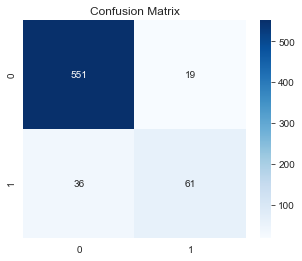

In [264]:
# confusion matrix analysis
cm = confusion_matrix(y_test, y_pred_tuned)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


The confusion matrix shows how well the model distinguishes between churners and non-churners.

True Negatives (TN): 551

→ Customers correctly predicted as not churned

False Positives (FP): 19

→ Customers incorrectly predicted to churn

False Negatives (FN): 36

→ Customers who actually churned but were missed by the model

True Positives (TP): 61

→ Customers correctly identified as churners

Reducing false negatives is the key priority for this business problem.

### 9.4 BEST MODEL SELECTION

Based on evaluation results, the Tuned Decision Tree model provides the best balance of performance, particularly in terms of recall.
Although Logistic Regression is more interpretable, the tuned tree captures non-linear relationships better and improves churn detection.

# 10. Feature importance

Feature importance analysis shows which variables most influence churn prediction.
The most influential features can guide business strategies for customer retention, such as improving service quality or addressing customer complaints.

✅ Tuned model trained successfully

[9.1] Top 10 Important Features:
                   Feature  Importance
17  customer service calls    0.247564
2       international plan    0.218271
7         total day charge    0.210113
14      total intl minutes    0.078341
10        total eve charge    0.058282
3          voice mail plan    0.054057
8        total eve minutes    0.048644
5        total day minutes    0.041215
15        total intl calls    0.021947
67                state_WY    0.005863


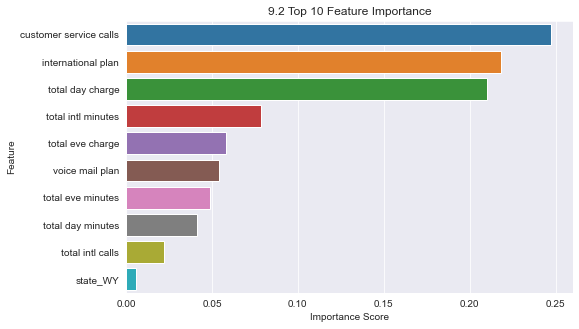

In [269]:
# re-training the model
from sklearn.tree import DecisionTreeClassifier

tuned_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

tuned_tree.fit(X_train, y_train)

print("✅ Tuned model trained successfully")

# running feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tuned_tree.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n[9.1] Top 10 Important Features:")
print(feature_importance.head(10))

# added visual
plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("9.2 Top 10 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# 11. key insights

 This section interprets the feature importance results from the tuned decision tree model in order to understand the key drivers of customer churn.  Feature importance allows us to identify which variables have the strongest influence on the model’s predictions. This helps translate the machine learning results into meaningful business insights.

#### Cost-related factors
(Total day charge, total evening charge, total international charge)
→ Customers with higher service costs are more likely to churn.
#### Customer service experience
(Customer service calls)
→ A high number of support calls indicates dissatisfaction and increases churn risk.
#### International service usage
(International plan, international charges, international calls)
→ Customers using international services show higher churn tendency due to higher costs.
#### High usage patterns
(Total day minutes, voicemail messages)
→ Heavy users may churn if pricing is not competitive or value is not perceived as fair.

# 12. LIMITATIONS

-The dataset is imbalanced, with far fewer churners than non-churners, which can affect model performance.

-The model does not incorporate external behavioral or financial data, which may improve prediction accuracy.

-Some misclassification of churners still occurs, meaning not all at-risk customers are captured.

# 13. recommendations

Improve pricing and customer support

# 14. conclusion

Model successfully completed churn prediction task